In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sv3.nn import SvenWrapper, MultiMLP
from sv3.sven import Sven

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


Train: 105 samples, Test: 45 samples
Features: 4, Classes: 3


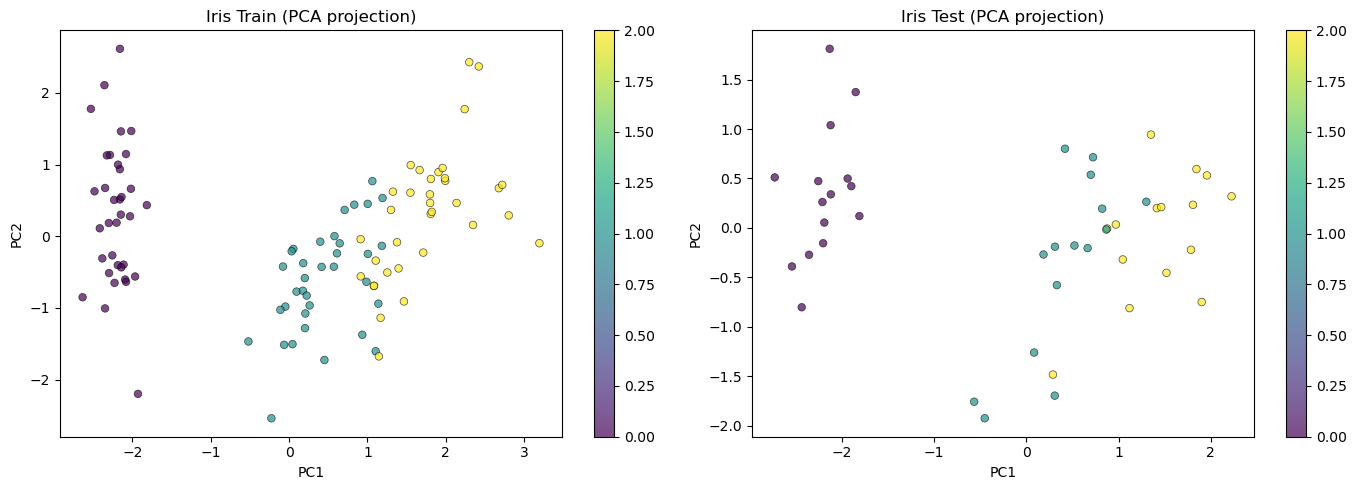

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset

iris = load_iris()
X, y = iris.data, iris.target  # (150, 4), 3 classes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

print(f"Train: {X_train_t.shape[0]} samples, Test: {X_test_t.shape[0]} samples")
print(f"Features: {X_train_t.shape[1]}, Classes: {len(np.unique(y_train))}")

# Visualize with PCA projection
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(X_train)
X_train_2d = pca.transform(X_train)
X_test_2d = pca.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, X_2d, labels, title in [
    (axes[0], X_train_2d, y_train, 'Train'),
    (axes[1], X_test_2d, y_test, 'Test'),
]:
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', alpha=0.7, s=30, edgecolors='k', linewidths=0.5)
    ax.set_title(f'Iris {title} (PCA projection)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax)
plt.tight_layout()

In [3]:
NUM_MODELS = 10

set_seed(437438)
mlp_base = MultiMLP(
    num_models=NUM_MODELS,
    input_dim=4,
    hidden_dims=[32, 32, 32],
    output_dim=3
)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base

In [4]:
LOADER_SEED = 645297
batch_size = 32
n_epoch = 50
K = 32
RTOL = 1e-2
LR = 1e-3

### Train MultiMLP ensemble with Adam

In [5]:
model_adam = MultiMLP(num_models=NUM_MODELS, input_dim=4, hidden_dims=[32, 32, 32], output_dim=3)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=1e-3)

def loss_fn_adam(pred, y):
    if pred.dim() == 3:
        M, B, C = pred.shape
        pred = pred.reshape(M * B, C)
        y = y.unsqueeze(0).expand(M, -1).reshape(M * B)
    return F.cross_entropy(pred, y)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn_adam, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device mps


100%|██████████| 50/50 [00:03<00:00, 14.36it/s]


### Train MultiMLP ensemble with SVD Optimizer

In [6]:
if device == torch.device('mps'):
    device = torch.device('cpu')

model_svd = MultiMLP(num_models=NUM_MODELS, input_dim=4, hidden_dims=[32, 32, 32], output_dim=3)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn_svd(pred, y):
    if pred.dim() == 3:
        M, B, C = pred.shape
        pred = pred.reshape(M * B, C)
        y = y.unsqueeze(0).expand(M, -1).reshape(M * B)
    return F.cross_entropy(pred, y, reduction='none')

model_svd = SvenWrapper(model_svd, loss_fn_svd, device=device)
optimizer = Sven(model_svd, lr=LR, k=K, rtol=RTOL, track_svd_info=True, svd_mode='randomized', use_rmsprop=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd, optimizer, loss_fn_svd, train_loader, test_loader, n_epoch, device, track_acc=True)
svd_info = optimizer.svd_info

torch.compiler.reset()

  0%|          | 0/50 [00:00<?, ?it/s]/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 50/50 [00:25<00:00,  1.98it/s]


### Compare Adam vs SVD

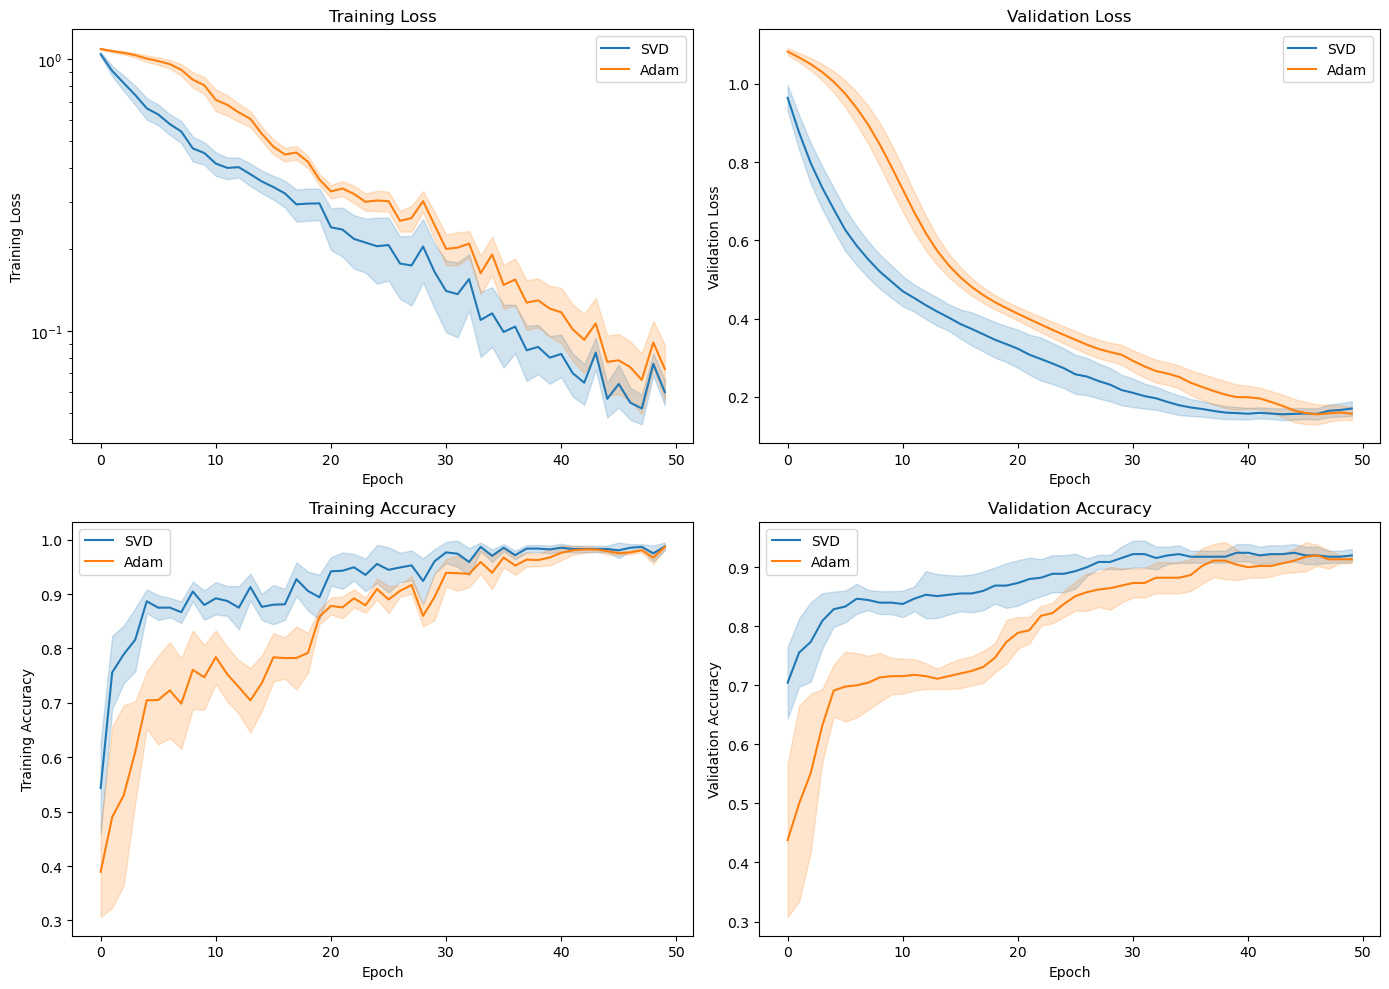

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = np.arange(len(losses_adam['train']))

for ax, key, title in [
    (axes[0, 0], 'train', 'Training Loss'),
    (axes[0, 1], 'val', 'Validation Loss'),
    (axes[1, 0], 'train_acc', 'Training Accuracy'),
    (axes[1, 1], 'val_acc', 'Validation Accuracy'),
]:
    for losses_dict, label, color in [
        (losses_svd, 'SVD', 'C0'),
        (losses_adam, 'Adam', 'C1'),
    ]:
        pm = np.array(losses_dict[f'{key}_per_model'])  # (num_epochs, M)
        mean = pm.mean(axis=1)
        std = pm.std(axis=1)
        ax.plot(epochs, mean, color=color, label=label)
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()

axes[0, 0].set_yscale('log')
plt.tight_layout()

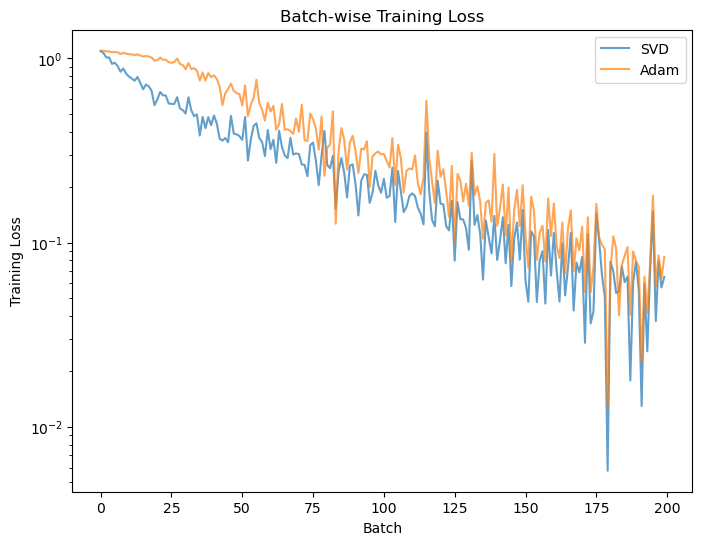

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(losses_svd['train_batch'], label='SVD', alpha=0.7)
plt.plot(losses_adam['train_batch'], label='Adam', alpha=0.7)
plt.legend()
plt.ylabel("Training Loss")
plt.xlabel("Batch")
plt.title("Batch-wise Training Loss")
plt.yscale('log')

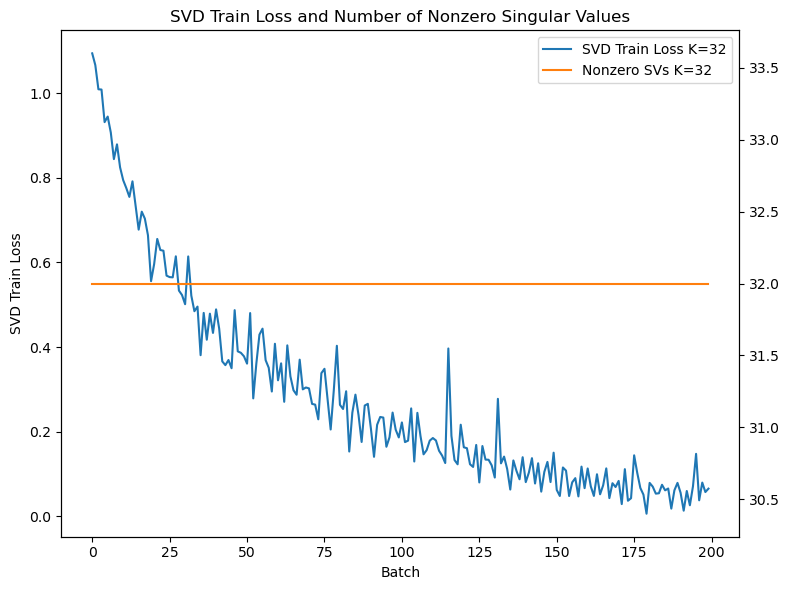

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 6))

p1 = ax1.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], 'C0', label=f'SVD Train Loss K={K}')
ax1.set_xlabel('Batch')
ax1.set_ylabel('SVD Train Loss')

ax2 = ax1.twinx()
p2 = ax2.plot(np.arange(len(svd_info['num_nonzero_svs'])), svd_info['num_nonzero_svs'], 'C1-', label=f'Nonzero SVs K={K}')

ax1.legend(handles=[p1[0], p2[0]])
plt.title("SVD Train Loss and Number of Nonzero Singular Values")
plt.tight_layout()

### Per-class Accuracy (Confusion Matrices)

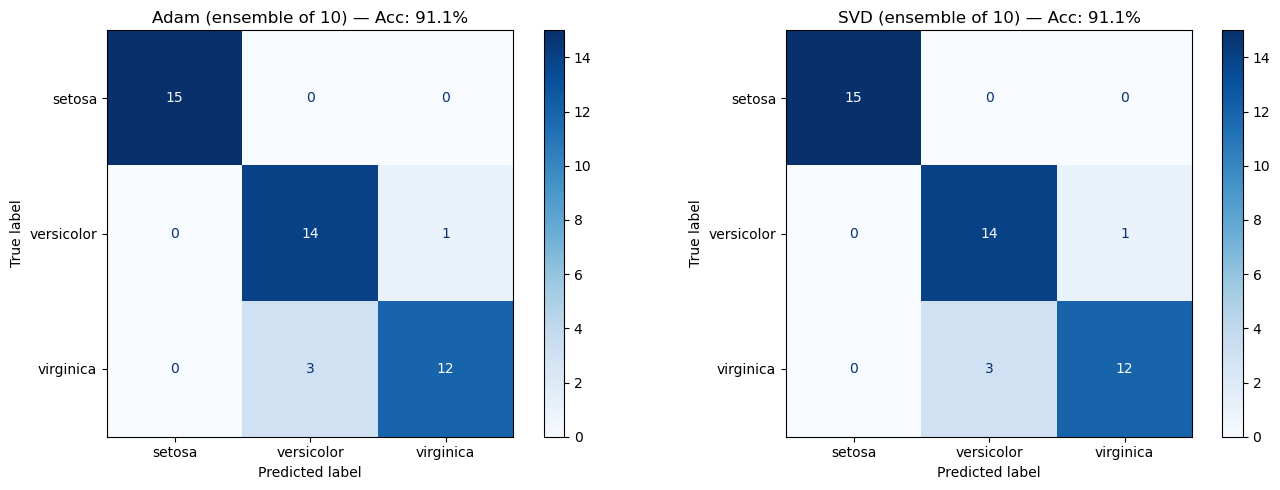

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title, is_functional in [
    (axes[0], model_adam, 'Adam', False),
    (axes[1], model_svd, 'SVD', True),
]:
    with torch.no_grad():
        if is_functional:
            logits = model.evaluate(X_test_t.to(device))
        else:
            model.eval()
            model = model.to('cpu')
            logits = model(X_test_t.to(device if not is_functional else 'cpu'))

        if logits.dim() == 3:
            # Ensemble: majority vote across models
            per_model_preds = torch.argmax(logits, dim=2)  # (M, N)
            preds = torch.mode(per_model_preds, dim=0).values.cpu().numpy()
        else:
            preds = torch.argmax(logits, dim=1).cpu().numpy()

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, cmap='Blues')
    acc = (preds == y_test).mean()
    ax.set_title(f'{title} (ensemble of {NUM_MODELS}) — Acc: {acc:.1%}')

plt.tight_layout()